# 🔍 Crawling Pemanfaatan Data Kota Surabaya — 

**Sumber yang di-crawl:**
| # | Sumber | Metode |
|---|--------|--------|
| 1 | Semantic Scholar API | REST API (pengganti Google Scholar) |
| 2 | Repositori ITS | Web Scraping (endpoint baru) |
| 3 | Repositori UNAIR | Web Scraping |
| 4 | Repositori UPN Veteran Jatim | Web Scraping |
| 5 | Repositori UBAYA | Web Scraping |
| 6 | Repositori UNESA | Web Scraping (URL diperbaiki) |
| 7 | Repositori UK Petra | Web Scraping (selector diperbaiki) |
| 8 | Open Data Surabaya | Web Scraping (bug selector fixed) |
| 9 | Kompas.com | RSS Feed (URL diperbaiki) |
| 10 | Detik.com | RSS Feed + header diperkuat |
| 11 | Tribun Surabaya | RSS Feed |
| 12 | Jawa Pos | RSS Feed |

**Filter:** Tahun 2025 ke atas  
**Output:** `hasil_crawling_surabaya.xlsx`


## Install & Import Library

In [1]:
import subprocess, sys
pkgs = ['requests', 'beautifulsoup4', 'openpyxl', 'feedparser', 'lxml', 'tqdm']
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs, check=True)
print('✅ Semua library berhasil diinstall!')

✅ Semua library berhasil diinstall!


In [2]:
import requests
from bs4 import BeautifulSoup
import feedparser
import pandas as pd
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import time, re
from datetime import datetime
from tqdm.notebook import tqdm
from IPython.display import display

# ── Header HTTP yang lebih lengkap agar tidak diblokir
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
    'Accept-Language': 'id-ID,id;q=0.9,en-US;q=0.8,en;q=0.7',
    'Accept-Encoding': 'gzip, deflate, br',
    'Connection': 'keep-alive',
}

TAHUN_MULAI = 2025   # ← ubah di sini jika perlu
OUTPUT_FILE = 'hasil_crawling_surabaya.xlsx'

print(f'✅ Setup selesai | Filter tahun: ≥ {TAHUN_MULAI}')

✅ Setup selesai | Filter tahun: ≥ 2025


---
## 1. Semantic Scholar API


In [3]:
SEMANTIC_QUERIES = [
    'data Surabaya machine learning',
    'Surabaya open data analysis',
    'Surabaya flood prediction',
    'Surabaya stunting poverty mapping',
    'Kota Surabaya clustering spatial',
    'Surabaya transportation public data',
    'Surabaya health disease dengue DBD',
    'Surabaya smart city government data',
    'Surabaya crime mapping analysis',
    'Surabaya education school data',
]

def crawl_semantic_scholar(queries, max_per_query=15, year_from=2025):
    BASE = 'https://api.semanticscholar.org/graph/v1/paper/search'
    results = []

    for query in tqdm(queries, desc='Semantic Scholar'):
        params = {
            'query': query,
            'limit': max_per_query,
            'fields': 'title,authors,year,abstract,externalIds,venue,url',
            'year': f'{year_from}-',
        }
        # Retry otomatis saat kena rate limit 429
        for attempt in range(3):
            try:
                r = requests.get(BASE, params=params, headers=HEADERS, timeout=15)
                if r.status_code == 429:
                    wait = 10 * (attempt + 1)
                    print(f'  ⏳ Rate limit 429, tunggu {wait}s...')
                    time.sleep(wait)
                    continue
                r.raise_for_status()
                for p in r.json().get('data', []):
                    yr = p.get('year') or 0
                    if int(yr) < year_from:
                        continue
                    results.append({
                        'Sumber'       : 'Semantic Scholar',
                        'Judul'        : p.get('title', ''),
                        'Penulis'      : ', '.join(a.get('name','') for a in p.get('authors',[])),
                        'Tahun'        : yr,
                        'Venue/Jurnal' : p.get('venue', ''),
                        'Abstrak'      : (p.get('abstract') or '')[:600],
                        'DOI'          : p.get('externalIds', {}).get('DOI', ''),
                        'URL'          : p.get('url', ''),
                        'Query'        : query,
                    })
                break  # sukses, keluar dari retry loop
            except Exception as e:
                if attempt == 2:
                    print(f'  ⚠️  [{query}]: {e}')
                time.sleep(3)
        time.sleep(2)  # jeda antar query

    # Hapus duplikat
    seen, unique = set(), []
    for r in results:
        key = r['Judul'].lower().strip()
        if key not in seen and len(key) > 5:
            seen.add(key); unique.append(r)

    print(f'✅ Semantic Scholar: {len(unique)} paper unik')
    return unique

df_semantic = pd.DataFrame(crawl_semantic_scholar(SEMANTIC_QUERIES, year_from=TAHUN_MULAI))
if not df_semantic.empty:
    display(df_semantic[['Judul','Penulis','Tahun','Venue/Jurnal']].head(5))

Semantic Scholar:   0%|          | 0/10 [00:00<?, ?it/s]

  ⏳ Rate limit 429, tunggu 10s...
  ⏳ Rate limit 429, tunggu 20s...
  ⏳ Rate limit 429, tunggu 30s...
  ⏳ Rate limit 429, tunggu 10s...
  ⏳ Rate limit 429, tunggu 20s...
  ⏳ Rate limit 429, tunggu 30s...
  ⏳ Rate limit 429, tunggu 10s...
  ⏳ Rate limit 429, tunggu 20s...
  ⏳ Rate limit 429, tunggu 30s...
  ⏳ Rate limit 429, tunggu 10s...
  ⏳ Rate limit 429, tunggu 10s...
  ⏳ Rate limit 429, tunggu 20s...
  ⏳ Rate limit 429, tunggu 30s...
  ⏳ Rate limit 429, tunggu 10s...
  ⏳ Rate limit 429, tunggu 20s...
  ⏳ Rate limit 429, tunggu 10s...
  ⏳ Rate limit 429, tunggu 10s...
  ⏳ Rate limit 429, tunggu 20s...
  ⏳ Rate limit 429, tunggu 30s...
  ⏳ Rate limit 429, tunggu 10s...
  ⏳ Rate limit 429, tunggu 20s...
  ⏳ Rate limit 429, tunggu 30s...
✅ Semantic Scholar: 56 paper unik


,Judul,Penulis,Tahun,Venue/Jurnal
0,Mapping and Forecasting District-Level Stuntin...,"I. Jaya, B. Tantular, Sinta Septi Pangastuti, ...",2026,Sustainability
1,Mapping Mangrove Species Distribution and Dens...,"L. M. Jaelani, D. Safitri, Naomy Elliana Krist...",2025,Journal of Human Earth and Future
2,Mapping Adolescents Vulnerable to Early Marria...,"D. Putri, Miftahul Jannah, Surya Dewi Puspita,...",2025,International Journal of Studies in Social Sci...
3,Spatial Analysis of Stunting Prevalence Accord...,"Y. Devi, M. Herdayati, M. Makful, Muthmainnah ...",2025,Media Publikasi Promosi Kesehatan Indonesia (M...
4,Can Air Quality Data Predict Stunting Prevalence?,"G. M. Perdananugraha, M. Nuryana, Y. Wismayanti",2026,Aerosol and Air Quality Research


---
## 2. Repositori Kampus

In [4]:
KAMPUS_CONFIG = [
    {
        'nama'     : 'ITS',
        'base_url' : 'https://repository.its.ac.id',
        # FIX: endpoint baru — coba POST ke halaman utama
        'search'   : 'https://repository.its.ac.id/cgi/search/simple',
        'search_alt': 'https://repository.its.ac.id/',
        'engine'   : 'eprints',
    },
    {
        'nama'     : 'UNAIR',
        'base_url' : 'https://repository.unair.ac.id',
        'search'   : 'https://repository.unair.ac.id/cgi/search/simple',
        'search_alt': 'https://repository.unair.ac.id/',
        'engine'   : 'eprints',
    },
    {
        'nama'     : 'UPN Veteran Jatim',
        'base_url' : 'https://eprints.upnjatim.ac.id',
        'search'   : 'https://eprints.upnjatim.ac.id/cgi/search/simple',
        'search_alt': 'https://eprints.upnjatim.ac.id/',
        'engine'   : 'eprints',
    },
    {
        'nama'     : 'UBAYA',
        'base_url' : 'https://repository.ubaya.ac.id',
        'search'   : 'https://repository.ubaya.ac.id/cgi/search/simple',
        'search_alt': 'https://repository.ubaya.ac.id/',
        'engine'   : 'eprints',
    },
    {
        'nama'     : 'UNESA',
        'base_url' : 'https://ejournal.unesa.ac.id',
        # FIX: URL pencarian OJS yang benar
        'search'   : 'https://ejournal.unesa.ac.id/index.php/index/search/search',
        'search_alt': 'https://ejournal.unesa.ac.id/index.php/index/search',
        'engine'   : 'ojs',
    },
    {
        'nama'     : 'UK Petra',
        'base_url' : 'https://dewey.petra.ac.id',
        # FIX: URL katalog yang benar
        'search'   : 'https://dewey.petra.ac.id/catalog/search',
        'search_alt': 'https://dewey.petra.ac.id/catalog/',
        'engine'   : 'petra',
    },
]

REPO_KEYWORDS = [
    'data Surabaya',
    'open data Surabaya',
    'analisis data Surabaya',
    'pemetaan Surabaya',
    'prediksi Surabaya',
    'Surabaya machine learning',
    'Surabaya deep learning',
    'Surabaya clustering',
    'Surabaya GIS spasial',
]

print(f'📚 Total kampus: {len(KAMPUS_CONFIG)}')
print(f'🔑 Total keyword: {len(REPO_KEYWORDS)}')

📚 Total kampus: 6
🔑 Total keyword: 9


In [5]:
def safe_get(url, params=None, timeout=30):
    """GET dengan retry 2x dan fallback."""
    for attempt in range(2):
        try:
            r = requests.get(url, params=params, headers=HEADERS, timeout=timeout)
            r.raise_for_status()
            return r
        except Exception as e:
            if attempt == 1:
                raise
            time.sleep(3)

def extract_year(text):
    m = re.search(r'\b(20[12]\d)\b', text)
    return int(m.group(1)) if m else 0


# ── EPrints: ITS, UNAIR, UPN, UBAYA
def scrape_eprints(kampus, keywords, max_per_kw=10, year_from=2025):
    results = []
    for kw in keywords:
        # Coba endpoint utama dulu, fallback ke alt jika gagal
        for search_url in [kampus['search'], kampus.get('search_alt', '')]:
            if not search_url:
                continue
            params = {
                'q'              : kw,
                '_action_search' : 'Search',
                'order'          : '-date',
                'satisfyall'     : 'ALL',
                'screen'         : 'Search',
            }
            try:
                r = safe_get(search_url, params=params, timeout=30)
                soup = BeautifulSoup(r.text, 'lxml')

                # EPrints punya beberapa variasi selector
                items = (
                    soup.select('table.ep_search_results tr') or
                    soup.select('div.ep_search_result') or
                    soup.select('div.ep_block_contents a') or
                    soup.select('li.summary_item') or
                    []
                )

                count = 0
                for item in items:
                    if count >= max_per_kw:
                        break
                    a_tag = item.select_one('a') if item.name != 'a' else item
                    if not a_tag or len(a_tag.get_text(strip=True)) < 5:
                        continue
                    title = a_tag.get_text(strip=True)
                    href  = a_tag.get('href', '')
                    url   = href if href.startswith('http') else kampus['base_url'] + href
                    meta  = item.get_text(separator=' ', strip=True)

                    year = extract_year(meta)
                    if year and year < year_from:
                        continue

                    penulis = ''
                    m = re.search(r'^([^(]+?)(?:\(|\d{4})', meta)
                    if m:
                        penulis = m.group(1).strip().strip('.')[:100]

                    results.append({
                        'Sumber'       : f'Repositori {kampus["nama"]}',
                        'Judul'        : title,
                        'Penulis'      : penulis,
                        'Tahun'        : year or '',
                        'Venue/Jurnal' : kampus['nama'],
                        'Abstrak'      : meta[:400],
                        'DOI'          : '',
                        'URL'          : url,
                        'Query'        : kw,
                    })
                    count += 1

                if count > 0:
                    break  # endpoint ini berhasil, tidak perlu coba alt
                time.sleep(2)

            except Exception as e:
                print(f'    ⚠️  {kampus["nama"]} [{kw}] @ {search_url}: {type(e).__name__}: {e}')

        time.sleep(1.5)
    return results


# ── OJS: UNESA
def scrape_ojs(kampus, keywords, max_per_kw=10, year_from=2025):
    results = []
    for kw in keywords:
        for search_url in [kampus['search'], kampus.get('search_alt', '')]:
            if not search_url:
                continue
            try:
                params = {'query': kw, 'searchField': 'query'}
                r = safe_get(search_url, params=params, timeout=40)
                soup = BeautifulSoup(r.text, 'lxml')

                # OJS v3 dan v2 punya selector berbeda
                items = (
                    soup.select('li.obj_article_summary') or
                    soup.select('div.article-summary') or
                    soup.select('div.result-title') or
                    soup.select('table.listing td.title') or
                    []
                )

                count = 0
                for item in items:
                    if count >= max_per_kw:
                        break
                    a_tag = item.select_one('h3.title a, a.title, a')
                    if not a_tag:
                        continue
                    title = a_tag.get_text(strip=True)
                    if len(title) < 5:
                        continue
                    href = a_tag.get('href', '')
                    url  = href if href.startswith('http') else kampus['base_url'] + href
                    meta = item.get_text(separator=' ', strip=True)

                    year = extract_year(meta)
                    if year and year < year_from:
                        continue

                    results.append({
                        'Sumber'       : f'Repositori {kampus["nama"]}',
                        'Judul'        : title,
                        'Penulis'      : '',
                        'Tahun'        : year or '',
                        'Venue/Jurnal' : kampus['nama'],
                        'Abstrak'      : meta[:400],
                        'DOI'          : '',
                        'URL'          : url,
                        'Query'        : kw,
                    })
                    count += 1

                if count > 0:
                    break
                time.sleep(2)

            except Exception as e:
                print(f'    ⚠️  UNESA [{kw}]: {type(e).__name__}: {e}')

        time.sleep(1.5)
    return results


# ── UK Petra (Dewey catalog) — FIX: selector diperbaiki
def scrape_petra(kampus, keywords, max_per_kw=10, year_from=2025):
    results = []
    for kw in keywords:
        for search_url in [kampus['search'], kampus.get('search_alt', '')]:
            if not search_url:
                continue
            try:
                # Dewey pakai parameter 'search[t]' untuk judul atau 'search[q]' untuk keyword
                params = {'search[q]': kw, 'limit': max_per_kw}
                r = safe_get(search_url, params=params, timeout=30)
                soup = BeautifulSoup(r.text, 'lxml')

                # Coba beberapa selector yang mungkin
                items = (
                    soup.select('div.results-item') or
                    soup.select('tr.result-row') or
                    soup.select('div.col-md-9') or
                    soup.select('h2.title a') or  # jika langsung link judul
                    soup.select('a.title') or
                    []
                )

                count = 0
                for item in items:
                    if count >= max_per_kw:
                        break
                    a_tag = item if item.name == 'a' else item.select_one('a')
                    if not a_tag:
                        continue
                    title = a_tag.get_text(strip=True)
                    if len(title) < 5:
                        continue
                    href = a_tag.get('href', '')
                    url  = href if href.startswith('http') else kampus['base_url'] + href
                    meta = item.get_text(separator=' ', strip=True) if item.name != 'a' else title

                    year = extract_year(meta)
                    if year and year < year_from:
                        continue

                    results.append({
                        'Sumber'       : f'Repositori {kampus["nama"]}',
                        'Judul'        : title,
                        'Penulis'      : '',
                        'Tahun'        : year or '',
                        'Venue/Jurnal' : 'UK Petra',
                        'Abstrak'      : meta[:400],
                        'DOI'          : '',
                        'URL'          : url,
                        'Query'        : kw,
                    })
                    count += 1

                if count > 0:
                    break
                time.sleep(2)

            except Exception as e:
                print(f'    ⚠️  UK Petra [{kw}]: {type(e).__name__}: {e}')

        time.sleep(1.5)
    return results


print('Fungsi scraping kampus siap!')

✅ Fungsi scraping kampus siap!


In [6]:
all_repo_results = []

for kampus in tqdm(KAMPUS_CONFIG, desc='Crawling Repositori Kampus'):
    print(f'\n📚 {kampus["nama"]} ({kampus["engine"]})...')
    if kampus['engine'] == 'eprints':
        hasil = scrape_eprints(kampus, REPO_KEYWORDS, year_from=TAHUN_MULAI)
    elif kampus['engine'] == 'ojs':
        hasil = scrape_ojs(kampus, REPO_KEYWORDS, year_from=TAHUN_MULAI)
    elif kampus['engine'] == 'petra':
        hasil = scrape_petra(kampus, REPO_KEYWORDS, year_from=TAHUN_MULAI)
    else:
        hasil = []

    # Hapus duplikat
    seen, unique = set(), []
    for item in hasil:
        key = item['Judul'].lower().strip()
        if key not in seen and len(key) > 5:
            seen.add(key); unique.append(item)

    print(f'   → {len(unique)} hasil unik')
    all_repo_results.extend(unique)

df_repo = pd.DataFrame(all_repo_results)
print(f'\n✅ Total repositori kampus: {len(df_repo)} hasil')
if not df_repo.empty:
    display(df_repo.groupby('Sumber')['Judul'].count().rename('Jumlah'))

Crawling Repositori Kampus:   0%|          | 0/6 [00:00<?, ?it/s]


📚 ITS (eprints)...
    ⚠️  ITS [data Surabaya] @ https://repository.its.ac.id/cgi/search/simple: HTTPError: 500 Server Error: Internal Server Error for url: https://repository.its.ac.id/cgi/search/simple?q=data+Surabaya&_action_search=Search&order=-date&satisfyall=ALL&screen=Search
    ⚠️  ITS [open data Surabaya] @ https://repository.its.ac.id/cgi/search/simple: HTTPError: 500 Server Error: Internal Server Error for url: https://repository.its.ac.id/cgi/search/simple?q=open+data+Surabaya&_action_search=Search&order=-date&satisfyall=ALL&screen=Search
    ⚠️  ITS [analisis data Surabaya] @ https://repository.its.ac.id/cgi/search/simple: HTTPError: 500 Server Error: Internal Server Error for url: https://repository.its.ac.id/cgi/search/simple?q=analisis+data+Surabaya&_action_search=Search&order=-date&satisfyall=ALL&screen=Search
    ⚠️  ITS [pemetaan Surabaya] @ https://repository.its.ac.id/cgi/search/simple: HTTPError: 500 Server Error: Internal Server Error for url: https://repository

,Jumlah
Sumber,
Repositori UK Petra,8


---
## 3. Crawling Berita


In [7]:
# Keyword lebih luas agar banyak berita tertangkap
BERITA_KEYWORDS = [
    'data Surabaya',
    'open data Surabaya',
    'Dinkominfo Surabaya',
    'Satu Data Surabaya',
    'smart city Surabaya',
    'big data Surabaya',
    'inovasi Surabaya',
    'teknologi Surabaya',
    'digital Surabaya',
    'aplikasi Surabaya',
    'sistem informasi Surabaya',
]

# RSS Feed — URL diperbaiki berdasarkan format aktual 2024-2025
RSS_SOURCES = {
    'Kompas.com': [
        'https://rss.kompas.com/opsional/rss/regional/surabaya',
        'https://rss.kompas.com/opsional/rss/regional/jawa-timur',
        'https://www.kompas.com/tag/surabaya?format=rss',
    ],
    'Detik.com': [
        'https://news.detik.com/berita/d-rss',
        'https://finance.detik.com/rss',
        'https://inet.detik.com/rss',
    ],
    'Tribun Surabaya': [
        'https://surabaya.tribunnews.com/rss',
        'https://www.tribunnews.com/tag/surabaya.rss',
    ],
    'Jawa Pos': [
        'https://www.jawapos.com/surabaya/feed/',
        'https://www.jawapos.com/feed/',
    ],
}

print('✅ Konfigurasi berita siap!')
print(f'   Keyword: {len(BERITA_KEYWORDS)} kata kunci')

✅ Konfigurasi berita siap!
   Keyword: 11 kata kunci


In [8]:
def is_relevant(text, keywords):
    text_lower = text.lower()
    return any(kw.lower() in text_lower for kw in keywords)

def parse_year_rss(entry):
    for f in ['published_parsed', 'updated_parsed']:
        v = getattr(entry, f, None)
        if v: return v.tm_year
    raw = getattr(entry, 'published', '') or getattr(entry, 'updated', '')
    m = re.search(r'\b(20\d{2})\b', raw)
    return int(m.group(1)) if m else 0

def parse_date_rss(entry):
    raw = getattr(entry, 'published', '') or getattr(entry, 'updated', '')
    return raw[:25] if raw else ''


def crawl_rss(rss_sources, keywords, year_from=2025):
    results = []

    for sumber, feeds in tqdm(rss_sources.items(), desc='Crawling Berita'):
        for feed_url in feeds:
            try:
                # feedparser pakai requests terpisah agar bisa set header
                resp = requests.get(feed_url, headers=HEADERS, timeout=15)
                feed = feedparser.parse(resp.text)

                if not feed.entries:
                    # Coba langsung via feedparser
                    feed = feedparser.parse(feed_url)

                for entry in feed.entries:
                    title   = entry.get('title', '')
                    summary = entry.get('summary', '') or entry.get('description', '')
                    link    = entry.get('link', '')
                    year    = parse_year_rss(entry)

                    if year and year < year_from:
                        continue
                    if not is_relevant(title + ' ' + summary, keywords):
                        continue

                    clean = BeautifulSoup(summary, 'lxml').get_text()[:500]
                    matched = [kw for kw in keywords if kw.lower() in (title+' '+summary).lower()]

                    results.append({
                        'Sumber'        : sumber,
                        'Judul'         : title,
                        'Ringkasan'     : clean,
                        'Tahun'         : year or '',
                        'Tanggal'       : parse_date_rss(entry),
                        'URL'           : link,
                        'Keyword Cocok' : ', '.join(matched),
                    })

                time.sleep(1)
            except Exception as e:
                print(f'  ⚠️  {sumber} [{feed_url}]: {type(e).__name__}: {e}')

    # Hapus duplikat
    seen, unique = set(), []
    for item in results:
        key = item['Judul'].lower().strip()
        if key not in seen and len(key) > 5:
            seen.add(key); unique.append(item)

    print(f'✅ Total berita relevan: {len(unique)}')
    return unique


berita_results = crawl_rss(RSS_SOURCES, BERITA_KEYWORDS, year_from=TAHUN_MULAI)
df_berita = pd.DataFrame(berita_results)
if not df_berita.empty:
    display(df_berita.groupby('Sumber')['Judul'].count().rename('Jumlah Berita'))
    display(df_berita[['Sumber','Judul','Tanggal','URL']].head(5))

Crawling Berita:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Total berita relevan: 0


---
## 4. Open Data Surabaya


In [9]:
def crawl_opendata_surabaya(max_pages=10):
    BASE = 'https://opendata.surabaya.go.id/kumpulan_dataset'
    results = []
    seen_urls = set()

    for page in tqdm(range(1, max_pages + 1), desc='Open Data Surabaya'):
        try:
            r = safe_get(BASE, params={'page': page}, timeout=20)
            soup = BeautifulSoup(r.text, 'lxml')

            # FIX: Pakai find_all biasa — hindari CSS selector dengan tanda kutip dalam string
            cards = [
                a for a in soup.find_all('a', href=True)
                if '/kumpulan_dataset/' in a.get('href', '')
                and len(a.get('href', '')) > len('/kumpulan_dataset/')  # bukan halaman utama
            ]

            if not cards:
                print(f'  → Halaman {page}: kosong, selesai.')
                break

            for card in cards:
                href = card.get('href', '')
                full_url = href if href.startswith('http') else f'https://opendata.surabaya.go.id{href}'
                if full_url in seen_urls:
                    continue
                title = card.get_text(strip=True)
                if len(title) < 5:
                    continue

                parent = card.find_parent(['div', 'li', 'article'])
                deskripsi = parent.get_text(separator=' ', strip=True)[:300] if parent else ''

                seen_urls.add(full_url)
                results.append({
                    'Sumber'        : 'Open Data Surabaya',
                    'Judul Dataset' : title,
                    'Deskripsi'     : deskripsi,
                    'URL'           : full_url,
                    'Halaman'       : page,
                })

            print(f'  → Halaman {page}: {len([r for r in results if r["Halaman"]==page])} dataset')
            time.sleep(1.5)

        except Exception as e:
            print(f'  ⚠️  Halaman {page}: {type(e).__name__}: {e}')
            break

    print(f'✅ Open Data Surabaya: {len(results)} dataset')
    return results


opendata_results = crawl_opendata_surabaya(max_pages=10)
df_opendata = pd.DataFrame(opendata_results)
if not df_opendata.empty:
    display(df_opendata.head(5))

Open Data Surabaya:   0%|          | 0/10 [00:00<?, ?it/s]

  → Halaman 1: 10 dataset
  → Halaman 2: 10 dataset
  → Halaman 3: 10 dataset
  → Halaman 4: 10 dataset
  → Halaman 5: 10 dataset
  → Halaman 6: 10 dataset
  → Halaman 7: 10 dataset
  → Halaman 8: 10 dataset
  → Halaman 9: 10 dataset
  → Halaman 10: 10 dataset
✅ Open Data Surabaya: 100 dataset


,Sumber,Judul Dataset,Deskripsi,URL,Halaman
0,Open Data Surabaya,"Jumlah Rumah Sakit yang Ditingkatkan Sarana, P...",1802 data ditemukan Jumlah Rumah Sakit yang Di...,https://opendata.surabaya.go.id/kumpulan_datas...,1
1,Open Data Surabaya,Jumlah fasilitas kesehatan yang melakukan perb...,1802 data ditemukan Jumlah Rumah Sakit yang Di...,https://opendata.surabaya.go.id/kumpulan_datas...,1
2,Open Data Surabaya,Jumlah Rumah Sakit dengan status memenuhi stan...,1802 data ditemukan Jumlah Rumah Sakit yang Di...,https://opendata.surabaya.go.id/kumpulan_datas...,1
3,Open Data Surabaya,Jumlah Rumah Sakit yang bekerjasama dalam Jami...,1802 data ditemukan Jumlah Rumah Sakit yang Di...,https://opendata.surabaya.go.id/kumpulan_datas...,1
4,Open Data Surabaya,Jumlah rumah sakit milik pemerintah kota surab...,1802 data ditemukan Jumlah Rumah Sakit yang Di...,https://opendata.surabaya.go.id/kumpulan_datas...,1


---
## 5. Ringkasan & Ekspor ke Excel

In [10]:
ringkasan = {
    'Semantic Scholar'         : len(df_semantic)  if not df_semantic.empty  else 0,
    'Repositori Kampus (total)': len(df_repo)      if not df_repo.empty      else 0,
    'Berita'                   : len(df_berita)    if not df_berita.empty    else 0,
    'Open Data Surabaya'       : len(df_opendata)  if not df_opendata.empty  else 0,
}

print('=' * 52)
print('  📋 RINGKASAN HASIL CRAWLING')
print('=' * 52)
for k, v in ringkasan.items():
    print(f'  {k:<32}: {v:>5} data')
print(f'  {"─"*44}')
print(f'  {"TOTAL":<32}: {sum(ringkasan.values()):>5} data')
print('=' * 52)

if not df_repo.empty:
    print('\n📚 Detail per Kampus:')
    display(df_repo.groupby('Sumber')['Judul'].count().rename('Jumlah'))

  📋 RINGKASAN HASIL CRAWLING
  Semantic Scholar                :    56 data
  Repositori Kampus (total)       :     8 data
  Berita                          :     0 data
  Open Data Surabaya              :   100 data
  ────────────────────────────────────────────
  TOTAL                           :   164 data

📚 Detail per Kampus:


,Jumlah
Sumber,
Repositori UK Petra,8


In [11]:
def export_excel(df_semantic, df_repo, df_berita, df_opendata, output_path):
    wb = openpyxl.Workbook()
    DARK = '1F4E79'; MED = '2E75B6'; LIGHT = 'BDD7EE'; ALT = 'EEF5FB'; WHITE = 'FFFFFF'
    thin = Side(style='thin', color='CCCCCC')
    bdr  = Border(left=thin, right=thin, top=thin, bottom=thin)

    def hdr(ws, r, c, v):
        cell = ws.cell(row=r, column=c, value=v)
        cell.font = Font(bold=True, color=WHITE, name='Arial', size=10)
        cell.fill = PatternFill('solid', start_color=DARK)
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
        cell.border = bdr

    def dat(ws, r, c, v, alt=False):
        cell = ws.cell(row=r, column=c, value=str(v) if v is not None else '')
        cell.font = Font(name='Arial', size=9)
        cell.fill = PatternFill('solid', start_color=ALT if alt else WHITE)
        cell.alignment = Alignment(vertical='top', wrap_text=True)
        cell.border = bdr

    def write_sheet(ws, title, df, widths):
        if df.empty: return
        headers = list(df.columns)
        n = len(headers)
        ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=n)
        c = ws.cell(row=1, column=1, value=title)
        c.font = Font(bold=True, color=WHITE, name='Arial', size=13)
        c.fill = PatternFill('solid', start_color=DARK)
        c.alignment = Alignment(horizontal='center', vertical='center')
        ws.row_dimensions[1].height = 28

        ws.merge_cells(start_row=2, start_column=1, end_row=2, end_column=n)
        info = ws.cell(row=2, column=1, value=f'Crawled: {datetime.now():%d %B %Y %H:%M} | Filter ≥ {TAHUN_MULAI} | Total: {len(df)}')
        info.font = Font(italic=True, name='Arial', size=9, color='555555')
        info.alignment = Alignment(horizontal='left')

        for ci, h in enumerate(headers, 1): hdr(ws, 3, ci, h)
        ws.row_dimensions[3].height = 22

        for ri, row in enumerate(df.itertuples(index=False), 4):
            for ci, v in enumerate(row, 1): dat(ws, ri, ci, v, alt=(ri%2==0))
            ws.row_dimensions[ri].height = 48

        for ci, w in enumerate(widths, 1):
            ws.column_dimensions[get_column_letter(ci)].width = w
        ws.freeze_panes = 'A4'
        ws.auto_filter.ref = f'A3:{get_column_letter(n)}3'

    # Sheet 1: Semantic Scholar
    ws1 = wb.active; ws1.title = 'Semantic Scholar'
    write_sheet(ws1, '📄 Semantic Scholar', df_semantic, [18,45,28,8,25,55,25,45,22])

    # Sheet 2-7: per kampus
    KAMPUS = ['ITS','UNAIR','UPN Veteran Jatim','UBAYA','UNESA','UK Petra']
    repo_cols = ['Sumber','Judul','Penulis','Tahun','Venue/Jurnal','Abstrak','DOI','URL','Query']
    for nm in KAMPUS:
        ws = wb.create_sheet(title=nm[:31])
        sub = df_repo[df_repo['Sumber']==f'Repositori {nm}'] if not df_repo.empty else pd.DataFrame()
        if not sub.empty:
            write_sheet(ws, f'🏫 Repositori {nm}', sub[repo_cols], [22,45,28,8,18,50,22,45,22])
        else:
            ws.cell(row=1, column=1, value=f'Belum ada data untuk {nm} (tahun ≥ {TAHUN_MULAI})')

    # Sheet 8: Berita
    ws_b = wb.create_sheet(title='Berita')
    write_sheet(ws_b, '📰 Berita', df_berita, [18,50,60,8,22,50,30])

    # Sheet 9: Open Data
    ws_od = wb.create_sheet(title='Open Data Surabaya')
    write_sheet(ws_od, '🌐 Open Data Surabaya', df_opendata, [22,55,65,50,10])

    # Sheet 10: Ringkasan
    ws_r = wb.create_sheet(title='Ringkasan')
    ws_r.column_dimensions['A'].width = 35
    ws_r.column_dimensions['B'].width = 18
    ws_r.merge_cells('A1:B1')
    c = ws_r.cell(row=1, column=1, value='RINGKASAN CRAWLING — PEMANFAATAN DATA KOTA SURABAYA')
    c.font = Font(bold=True, color=WHITE, name='Arial', size=13)
    c.fill = PatternFill('solid', start_color=DARK)
    c.alignment = Alignment(horizontal='center')
    ws_r.row_dimensions[1].height = 26

    rows = [
        ('Sumber Data', 'Jumlah'),
        ('Semantic Scholar', len(df_semantic) if not df_semantic.empty else 0),
        *[(f'Repositori {n}', len(df_repo[df_repo['Sumber']==f'Repositori {n}']) if not df_repo.empty else 0) for n in KAMPUS],
        ('Berita',  len(df_berita)   if not df_berita.empty   else 0),
        ('Open Data Surabaya', len(df_opendata) if not df_opendata.empty else 0),
        ('─' * 30, '─' * 12),
        ('TOTAL', f'=SUM(B3:B{2+1+len(KAMPUS)+2})'),
        ('', ''),
        ('Filter Tahun', f'≥ {TAHUN_MULAI}'),
        ('Tanggal Crawling', datetime.now().strftime('%d %B %Y')),
        ('Dibuat oleh', 'Peserta Magang Dinkominfo Surabaya'),
    ]
    for ri, (lbl, val) in enumerate(rows, 2):
        ca = ws_r.cell(row=ri, column=1, value=lbl)
        cb = ws_r.cell(row=ri, column=2, value=val)
        is_h = ri==2; is_t = str(lbl).startswith('TOTAL')
        fc = MED if is_h else (LIGHT if is_t else (ALT if ri%2==0 else WHITE))
        tc = WHITE if is_h else (DARK if is_t else '000000')
        for c in [ca, cb]:
            c.font = Font(bold=(is_h or is_t), name='Arial', size=10, color=tc)
            c.fill = PatternFill('solid', start_color=fc)
            c.alignment = Alignment(horizontal='center' if is_h else 'left', vertical='center')
            c.border = bdr

    wb.save(output_path)
    print(f'\n✅ Tersimpan: {output_path}')


export_excel(df_semantic, df_repo, df_berita, df_opendata, OUTPUT_FILE)
print('\n🎉 Selesai!')


✅ Tersimpan: hasil_crawling_surabaya.xlsx

🎉 Selesai!


---
##  6. Visualisasi

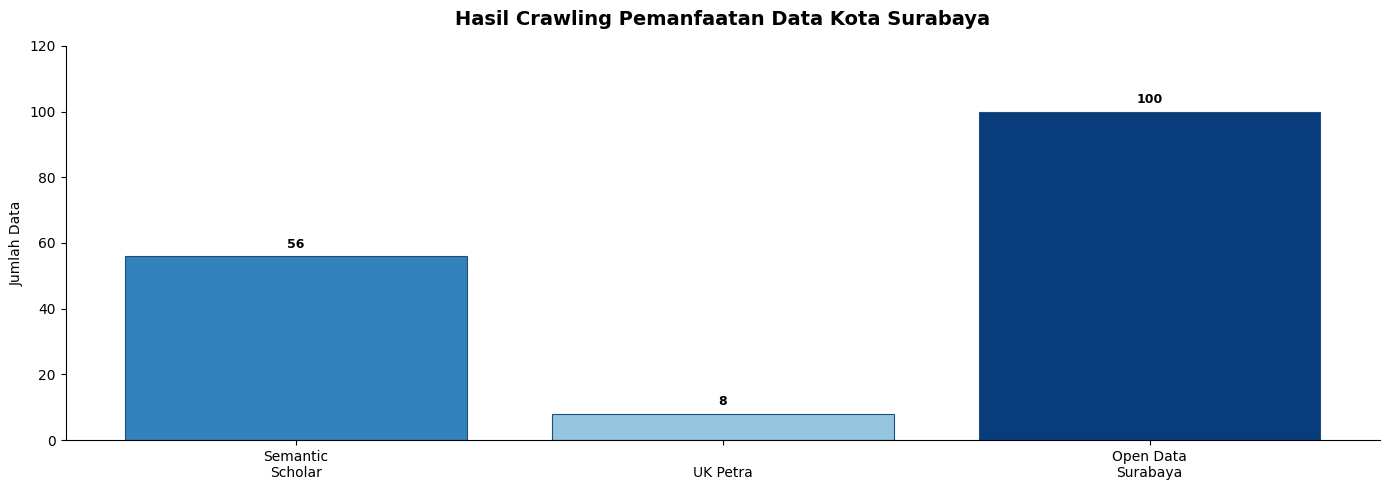

📊 Grafik disimpan: ringkasan_crawling.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['font.family'] = 'DejaVu Sans'

labels, values = [], []
if not df_semantic.empty:
    labels.append('Semantic\nScholar'); values.append(len(df_semantic))
if not df_repo.empty:
    for s, g in df_repo.groupby('Sumber'):
        labels.append(s.replace('Repositori ','\n')); values.append(len(g))
if not df_berita.empty:
    for s, g in df_berita.groupby('Sumber'):
        labels.append(s); values.append(len(g))
if not df_opendata.empty:
    labels.append('Open Data\nSurabaya'); values.append(len(df_opendata))

if values:
    colors = plt.cm.Blues([0.35 + 0.6*(v/max(values)) for v in values])
    fig, ax = plt.subplots(figsize=(max(14, len(labels)*1.5), 5))
    bars = ax.bar(labels, values, color=colors, edgecolor='#1F4E79', linewidth=0.8)
    ax.bar_label(bars, padding=4, fontsize=9, fontweight='bold')
    ax.set_title('Hasil Crawling Pemanfaatan Data Kota Surabaya', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Jumlah Data')
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylim(0, max(values)*1.2)
    plt.tight_layout()
    plt.savefig('ringkasan_crawling.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('📊 Grafik disimpan: ringkasan_crawling.png')
else:
    print('Belum ada data.')